# Voice Event Detection — Audio Processing Project
Detects whether a short audio clip is a sound **Event** or just **Background** noise, using the
pretrained voice model's prediction plus simple audio features as inputs to a new trained classifier.

**Before running:** unzip `converted_tflite.zip` once so `soundclassifier_with_metadata.tflite` and
`labels.txt` exist directly on disk, then set the paths in the **Configuration** cells below.

## Configuration

In [1]:
# Paths (change these to match your folders)
MODEL_PATH = "model/soundclassifier_with_metadata.tflite"
LABELS_PATH = "model/labels.txt"
SAVED_MODEL_PATH = "voice_event_model.keras"
SAVED_SCALER_PATH = "voice_scaler.pkl"

In [2]:
# Data settings
NUM_CLIPS = 300
SAMPLE_RATE = 16000
TEST_SIZE = 0.2
VAL_SIZE = 0.2
RANDOM_SEED = 42

# Sound settings: Event = tone burst, Background = quiet noise
EVENT_FREQ_RANGE = (100, 4000)       # tone pitch in Hz
EVENT_AMP_RANGE = (0.15, 0.9)        # tone loudness
EVENT_SECONDS_RANGE = (0.15, 1.0)    # tone length in seconds
EVENT_NOISE_MAX = 0.25               # noise level added to an Event clip
BACKGROUND_NOISE_MAX = 0.18          # noise level of a Background clip

# Classes (0 = Background, 1 = Event) and decision threshold
CLASS_NAMES = ["Background", "Event"]
THRESHOLD = 0.5

# Classifier settings
HIDDEN_UNITS = [16, 8]
EPOCHS = 20
BATCH_SIZE = 8

## 1. Import Libraries

In [3]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import wavfile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

In [4]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # hide TensorFlow info messages

import tensorflow as tf
import tf_keras as keras

In [5]:
warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

## 2. Load the Pretrained Voice Model

In [6]:
voice_interp = tf.lite.Interpreter(model_path=MODEL_PATH)
voice_interp.allocate_tensors()

voice_in = voice_interp.get_input_details()[0]
voice_out = voice_interp.get_output_details()[0]

In [7]:
with open(LABELS_PATH) as file:
    lines = file.read().splitlines()

voice_labels = []
for line in lines:
    voice_labels.append(line.split(" ", 1)[1])   # each line looks like "0 Background Noise"

In [8]:
clip_length = voice_in["shape"][1]   # number of audio samples the model expects

print("Input shape: ", voice_in["shape"])
print("Output shape:", voice_out["shape"])
print("Classes:     ", voice_labels)

Input shape:  [    1 44032]
Output shape: [1 9]
Classes:      ['Background Noise', 'Down', 'Left', 'No', 'On', 'Right', 'Stop', 'Up', 'Yes']


## 3. Prepare & Preprocess the Data
Generates labeled clips (Event = tone burst, Background = quiet noise), extracts simple audio
features, and integrates the pretrained model's own prediction as an extra feature.

In [9]:
def make_sample(is_event):
    t = np.arange(clip_length) / SAMPLE_RATE

    if is_event:
        freq = np.random.uniform(*EVENT_FREQ_RANGE)
        amp = np.random.uniform(*EVENT_AMP_RANGE)
        length = int(np.random.uniform(*EVENT_SECONDS_RANGE) * SAMPLE_RATE)
        start = np.random.randint(0, max(1, clip_length - length))

        envelope = np.zeros(clip_length)
        envelope[start:start + length] = 1.0
        noise = np.random.uniform(0, EVENT_NOISE_MAX) * np.random.uniform(-1, 1, clip_length)
        signal = amp * np.sin(2 * np.pi * freq * t) * envelope + noise
    else:
        signal = np.random.uniform(0, BACKGROUND_NOISE_MAX) * np.random.uniform(-1, 1, clip_length)

    return signal.astype(np.float32)

In [10]:
def predict_voice(audio):
    voice_interp.set_tensor(voice_in["index"], audio.reshape(1, -1))
    voice_interp.invoke()
    scores = voice_interp.get_tensor(voice_out["index"])[0]
    best = int(np.argmax(scores))
    return voice_labels[best], float(scores[best])


def extract_features(audio):
    rms = np.sqrt(np.mean(audio ** 2))                        # average loudness
    peak = np.max(np.abs(audio))                              # loudest point
    zcr = np.mean(np.abs(np.diff(np.sign(audio)))) / 2        # how often the wave crosses zero
    return rms, peak, zcr

In [11]:
ROW_COLUMNS = ["rms", "peak", "zcr", "tm_label", "tm_conf"]

def get_clip_row(audio):
    rms, peak, zcr = extract_features(audio)
    tm_label, tm_conf = predict_voice(audio)
    return [rms, peak, zcr, tm_label, tm_conf]

In [12]:
rows = []
for is_event in [0, 1]:
    for _ in range(NUM_CLIPS // 2):
        audio = make_sample(is_event)
        rows.append(get_clip_row(audio) + [is_event])

df = pd.DataFrame(rows, columns=ROW_COLUMNS + ["is_event"])
df.sample(5, random_state=RANDOM_SEED)

,rms,peak,zcr,tm_label,tm_conf,is_event
203,0.262737,0.939712,0.456905,Background Noise,0.999957,1
266,0.225356,0.665350,0.483841,Background Noise,0.999965,1
152,0.298533,0.917553,0.400286,Yes,0.468229,1
9,0.073692,0.127727,0.499239,Background Noise,0.999985,0
233,0.228954,0.680054,0.414776,Background Noise,0.999951,1


In [13]:
for class_index, class_name in enumerate(CLASS_NAMES):
    print(class_name, ":", (df["is_event"] == class_index).sum(), "clips")

Background : 150 clips
Event : 150 clips


In [14]:
# Split first, so the test clips stay completely unseen (also by the scaler)
train_df, test_df = train_test_split(
    df, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=df["is_event"]
)
fit_df, val_df = train_test_split(
    train_df, test_size=VAL_SIZE, random_state=RANDOM_SEED, stratify=train_df["is_event"]
)

print("Fit:", len(fit_df), " Validation:", len(val_df), " Test:", len(test_df))

Fit: 192  Validation: 48  Test: 60


In [15]:
NUMERIC_COLUMNS = ["rms", "peak", "zcr", "tm_conf"]

scaler = StandardScaler()
scaler.fit(fit_df[NUMERIC_COLUMNS])   # learn the scaling from the fit clips only


def make_features(table, fitted_scaler):
    numbers = fitted_scaler.transform(table[NUMERIC_COLUMNS])
    # one column per class of the voice model, always in the same order
    one_hot = pd.get_dummies(pd.Categorical(table["tm_label"], categories=voice_labels), dtype=np.float32)
    return np.hstack([numbers, one_hot.values]).astype(np.float32)

In [16]:
X_fit = make_features(fit_df, scaler)
X_val = make_features(val_df, scaler)
X_test = make_features(test_df, scaler)

y_fit = fit_df["is_event"].values
y_val = val_df["is_event"].values
y_test = test_df["is_event"].values

print("Feature shape:", X_fit.shape)

Feature shape: (192, 13)


## 4. Train the Classifier

In [17]:
event_model = keras.Sequential([keras.layers.Input(shape=(X_fit.shape[1],))])

for units in HIDDEN_UNITS:
    event_model.add(keras.layers.Dense(units, activation="relu"))

event_model.add(keras.layers.Dense(1, activation="sigmoid"))
event_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [18]:
history = event_model.fit(
    X_fit, y_fit,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0,
)

In [19]:
print("Train accuracy:", round(history.history["accuracy"][-1], 3))
print("Val accuracy:  ", round(history.history["val_accuracy"][-1], 3))

Train accuracy: 0.995
Val accuracy:   1.0


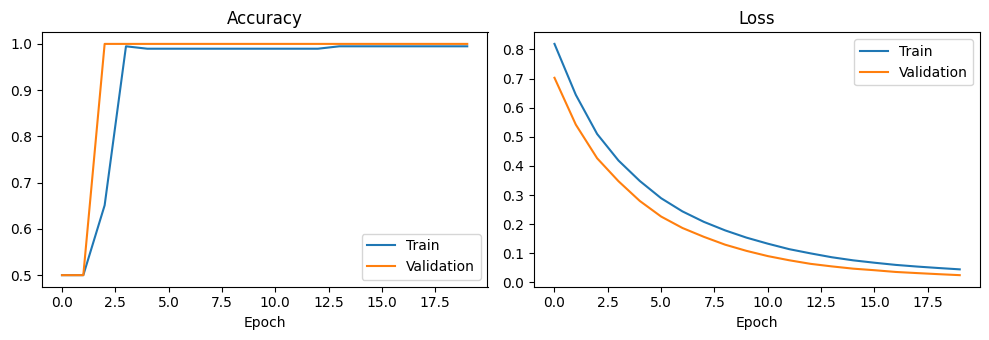

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax, metric in zip(axes, ["accuracy", "loss"]):
    ax.plot(history.history[metric], label="Train")
    ax.plot(history.history["val_" + metric], label="Validation")
    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Evaluate

In [21]:
y_prob = event_model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= THRESHOLD).astype(int)

In [22]:
print("Test accuracy:", round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Test accuracy: 1.0

              precision    recall  f1-score   support

  Background       1.00      1.00      1.00        30
       Event       1.00      1.00      1.00        30

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



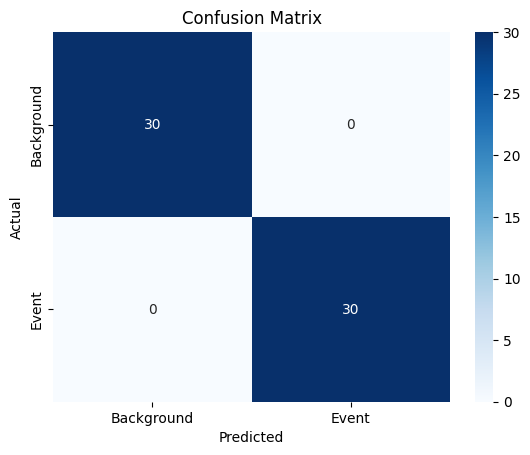

In [23]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

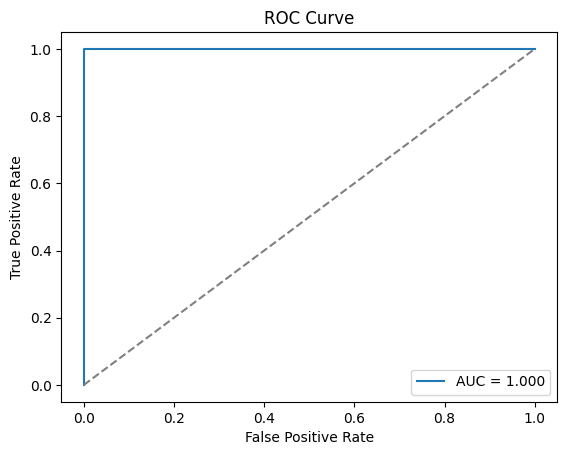

In [24]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 6. Save & Reload the Trained Model

In [25]:
event_model.save(SAVED_MODEL_PATH)
joblib.dump(scaler, SAVED_SCALER_PATH)
print("Saved:", SAVED_MODEL_PATH, "and", SAVED_SCALER_PATH)

Saved: voice_event_model.keras and voice_scaler.pkl


In [26]:
loaded_model = keras.models.load_model(SAVED_MODEL_PATH)
loaded_scaler = joblib.load(SAVED_SCALER_PATH)
print("Reloaded model input shape:", loaded_model.input_shape)

Reloaded model input shape: (None, 13)


## 7. Test on New Audio

In [27]:
def predict_audio(audio):
    row = pd.DataFrame([get_clip_row(audio)], columns=ROW_COLUMNS)

    prob = loaded_model.predict(make_features(row, loaded_scaler), verbose=0)[0, 0]
    decision = CLASS_NAMES[int(prob >= THRESHOLD)]

    print(f"TM model's own guess: {row['tm_label'][0]} ({round(row['tm_conf'][0] * 100, 1)}%)")
    print(f"Our trained model:    {decision} (confidence: {round(float(prob), 3)})")

In [28]:
for is_event_actual in [1, 0]:
    predict_audio(make_sample(is_event_actual))
    print("Actually was:        ", CLASS_NAMES[is_event_actual])
    print()

TM model's own guess: Background Noise (100.0%)
Our trained model:    Event (confidence: 1.0)
Actually was:         Event

TM model's own guess: Background Noise (100.0%)
Our trained model:    Background (confidence: 0.03)
Actually was:         Background



## 8. Test Your Own Audio (Manual Input)

In [29]:
wav_path = input("Enter the path of a .wav file: ").strip().strip('"')

Enter the path of a .wav file:  test_dataset/down_001.wav


In [30]:
rate, audio = wavfile.read(wav_path)
assert rate == SAMPLE_RATE, f"Please use a {SAMPLE_RATE} Hz wav file (yours is {rate} Hz)"

if np.issubdtype(audio.dtype, np.integer):
    audio = audio / np.iinfo(audio.dtype).max   # whole numbers -> -1 to 1
if audio.ndim > 1:
    audio = audio.mean(axis=1)                  # stereo -> mono

audio = audio[:clip_length]                     # cut to the length the model expects
audio = np.pad(audio, (0, clip_length - len(audio))).astype(np.float32)

In [31]:
predict_audio(audio)

TM model's own guess: Background Noise (nan%)
Our trained model:    Background (confidence: 0.479)
